In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../outputs/spotify_powerbi_ready.csv')
print(f"loaded {len(df):,} songs")
print(df['popularity_tier'].value_counts())

loaded 80,481 songs
popularity_tier
Low     48027
Mid     30098
High     2356
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

features = ['danceability', 'energy', 'valence', 'loudness', 'acousticness', 'instrumentalness']

X = df[features]
y = df['popularity_tier']

#data splitting for testing & training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print(f"training songs: {len(X_train):,}")
print(f"testing songs: {len(X_test):,}")

training songs: 64,384
testing songs: 16,097


In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# decisiontree model
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

# accuracy
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 61.33%


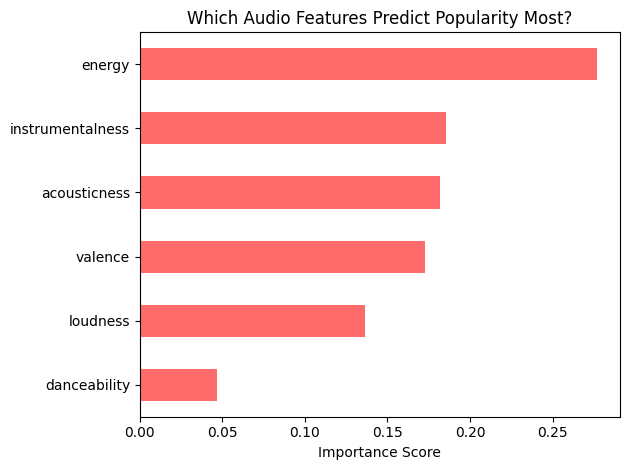

In [4]:
import matplotlib.pyplot as plt
#results
importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh', color='#FF6B6A')
plt.title('Which Audio Features Predict Popularity Most?')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150)
plt.show()

In [6]:
#song predicting
def predict_song(danceability, energy, valence, loudness, acousticness, instrumentalness):
    
    song = pd.DataFrame([[danceability, energy, valence, loudness, acousticness, instrumentalness]],
                        columns=features)
    
    result = model.predict(song)[0]
    
    print(f"Predicted Popularity: {result}")
    if result == 'High': print("high chances of being popular")
    elif result == 'Mid': print("moderate chances of being popular")
    else: print("may struggle to gain popularity")

predict_song(0.8, 0.7, 0.6, -5.0, 0.1, 0.0)


Predicted Popularity: Low
may struggle to gain popularity
